# Prédiction du risque d'abandon scolaire
**Auteur :** Koffi Koffi Ambroise  
**Cours :** Technologie de l'Intelligence Artificielle

**Numéro WhatsApp: +225 05 44 80 17 44**

---

## 1. Imports et chargement du dataset

In [104]:
#Imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
#Configurations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

#Reproductibilité
RANDOM_STATE = 42

In [106]:
#Chargement du dataset
path = '../data/raw/student_dropout_dataset.csv'
df = pd.read_csv(path)

#Affichage des dimensions
print(f"Shape: {df.shape}")
print(f"Nombre d'étudiants: {df.shape[0]}")
print(f"Nombre de variables: {df.shape[1]}")

#Aperu du dataset
print("\nAperçu du dataset:")
df.head()

Shape: (300, 8)
Nombre d'étudiants: 300
Nombre de variables: 8

Aperçu du dataset:


,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1


In [107]:
# Types de données et valeurs manquantes

print("\nTypes de données :")
print(df.dtypes)
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())
print("\nStatistiques descriptives:")
print(df.describe())


Types de données :
age                   int64
gender                  str
average_grade       float64
absenteeism_rate    float64
internet_access         str
study_time_hours    float64
extra_activities        str
dropout_risk          int64
dtype: object

Valeurs manquantes par colonne:
age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64

Statistiques descriptives:
              age  average_grade  absenteeism_rate  study_time_hours  \
count  300.000000     300.000000        300.000000        300.000000   
mean    19.326667      11.600067          0.257633          2.516000   
std      2.873001       3.705599          0.138460          1.341321   
min     15.000000       5.030000          0.000000          0.000000   
25%     17.000000       8.440000          0.147500          1.400000   
50%     19.000000      11.755000          0.260000          


 Distribution de la cible:
Non abandon (0): 227 étudiants (75.67%)
Abandon (1):     73 étudiants (24.33%)


C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_13824\803042979.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dropout_risk', ax=ax, palette=['#2ecc71', '#e74c3c'])


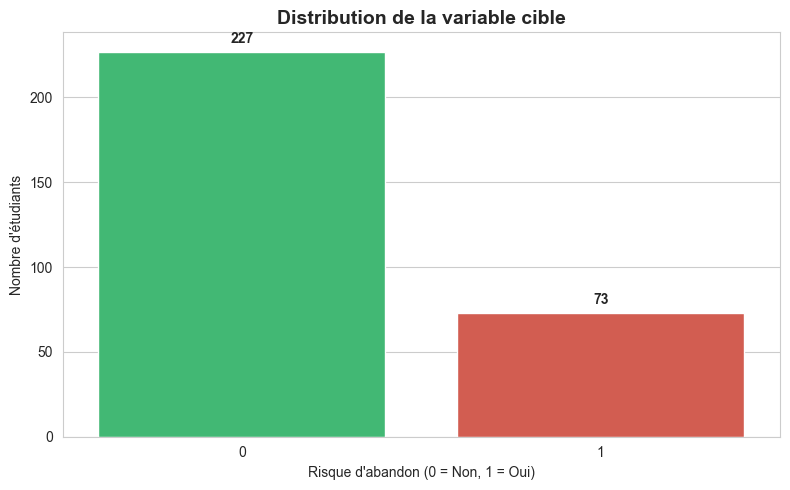

In [108]:
#Distribution de la variable cible
target_counts = df["dropout_risk"].value_counts()
target_pct = df["dropout_risk"].value_counts(normalize=True)*100

print("\n Distribution de la cible:")
print(f"Non abandon (0): {target_counts[0]} étudiants ({target_pct[0]:.2f}%)")
print(f"Abandon (1):     {target_counts[1]} étudiants ({target_pct[1]:.2f}%)")

#Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='dropout_risk', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
ax.set_xlabel('Risque d\'abandon (0 = Non, 1 = Oui)')
ax.set_ylabel('Nombre d\'étudiants')
for i, v in enumerate(target_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 2. Analyse exploratoire (EDA)

### 2.1 Distributions des variables numériques

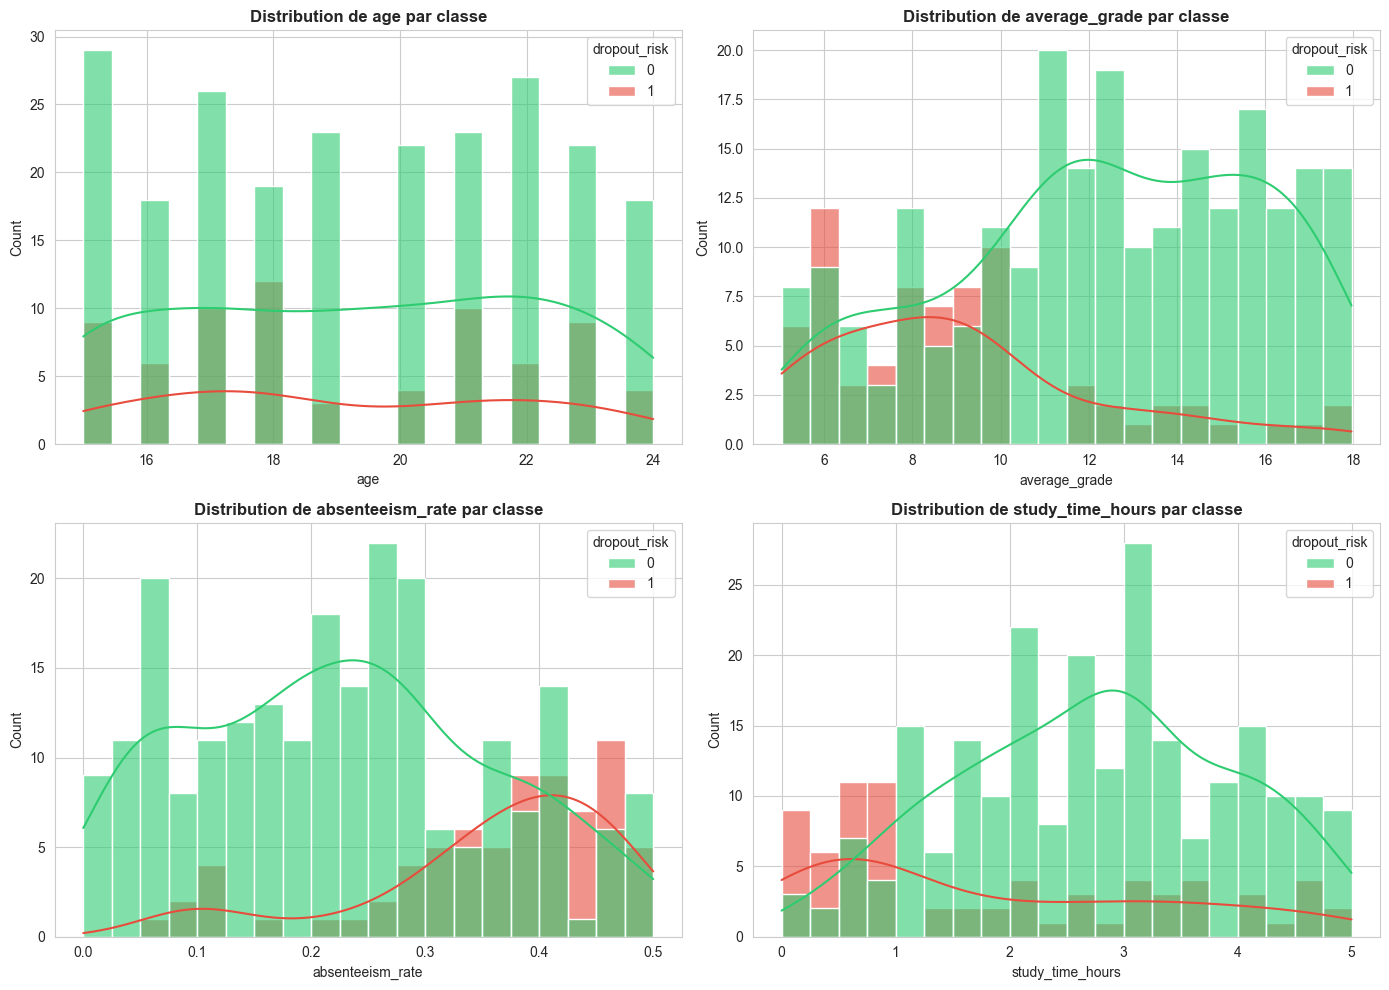

In [109]:
# Histogrammes des variables numériques
numeric_cols = ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, hue='dropout_risk', kde=True, ax=ax,
                 palette=['#2ecc71', '#e74c3c'], bins=20, alpha=0.6)
    ax.set_title(f'Distribution de {col} par classe', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

### 2.2 Analyse des variables catégorielles

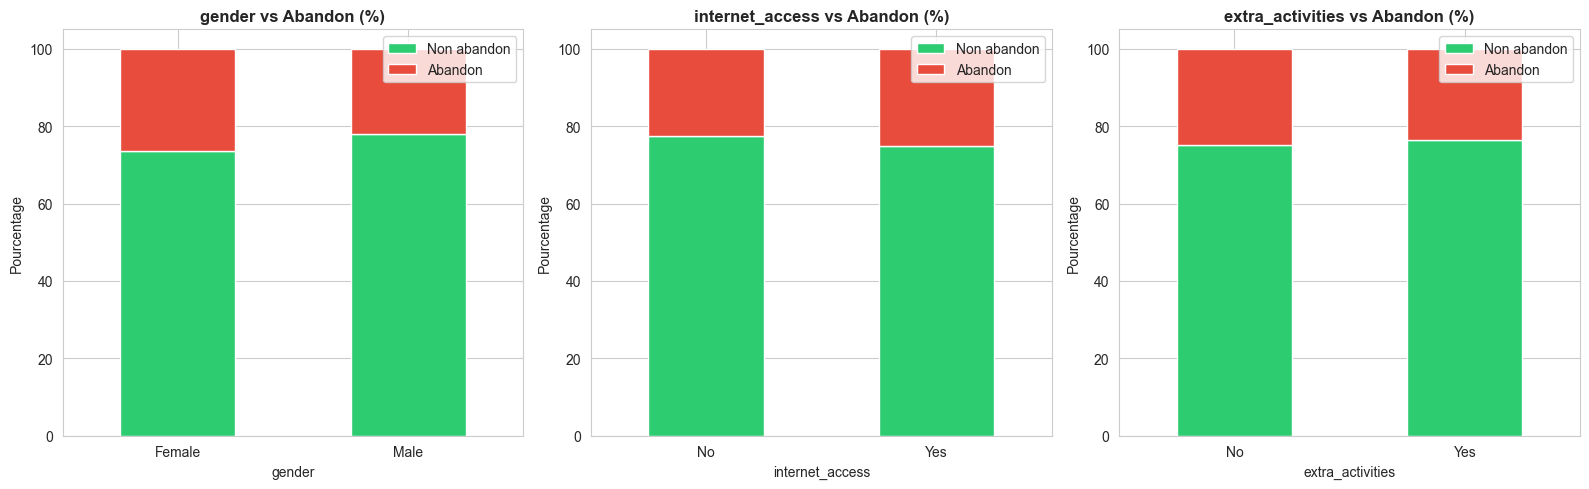

In [110]:
# Analyse des catégorielles vs cible
cat_cols = ['gender', 'internet_access', 'extra_activities']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['dropout_risk'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} vs Abandon (%)', fontweight='bold')
    ax.set_ylabel('Pourcentage')
    ax.legend(['Non abandon', 'Abandon'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/03_categorical.png', dpi=100, bbox_inches='tight')
plt.show()

### 2.3 Matrice de corrélation

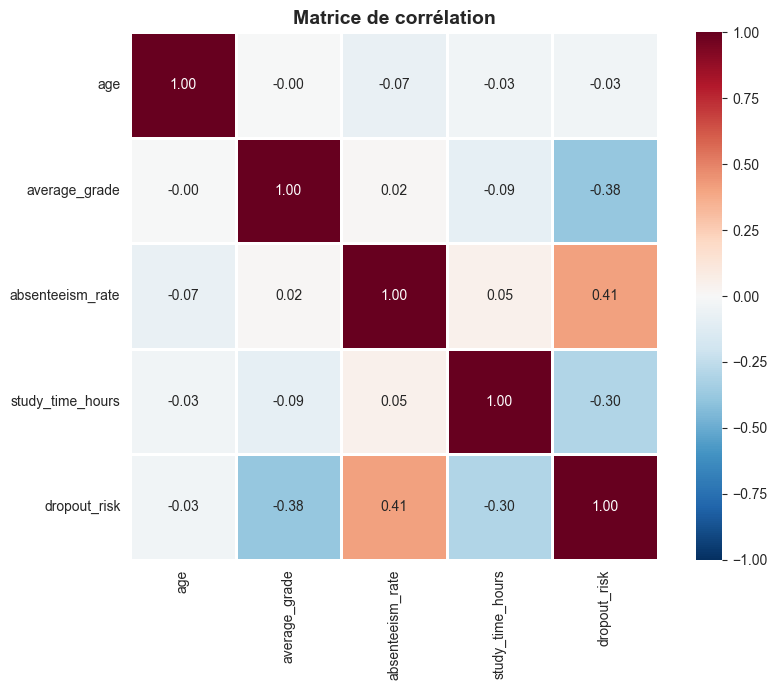


=== Corrélations avec dropout_risk ===
dropout_risk        1.000000
absenteeism_rate    0.412653
age                -0.032086
study_time_hours   -0.297416
average_grade      -0.384622
Name: dropout_risk, dtype: float64


In [111]:
# Matrice de corrélation (numériques uniquement)
corr = df[numeric_cols + ['dropout_risk']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

# Corrélations avec la cible
print("\n=== Corrélations avec dropout_risk ===")
print(corr['dropout_risk'].sort_values(ascending=False))

---
## 3. Prétraitement des données

- Pas de valeurs manquantes détectées 
- Encodage One-Hot des variables catégorielles
- Normalisation (Z-score) appliquée juste avant l'entraînement pour éviter le data leakage

In [112]:
# One-Hot Encoding des variables catégorielles
df_encoded = pd.get_dummies(df, columns=['gender', 'internet_access', 'extra_activities'], drop_first=True)

print("Colonnes après encodage :")
print(df_encoded.columns.tolist())
print(f"\nShape après encodage : {df_encoded.shape}")
df_encoded.head()

Colonnes après encodage :
['age', 'average_grade', 'absenteeism_rate', 'study_time_hours', 'dropout_risk', 'gender_Male', 'internet_access_Yes', 'extra_activities_Yes']

Shape après encodage : (300, 8)


,age,average_grade,absenteeism_rate,study_time_hours,dropout_risk,gender_Male,internet_access_Yes,extra_activities_Yes
0,21,16.27,0.35,4.1,0,True,True,False
1,18,12.30,0.38,0.2,1,False,False,False
2,22,8.10,0.04,3.4,0,True,False,False
3,19,13.84,0.25,4.8,0,True,False,True
4,21,14.62,0.47,0.6,1,False,True,True


---
## 4. Feature Engineering

Création de deux nouvelles variables pour renforcer le signal :
- **`attendance_rate`** : Taux de présence (1 - absenteeism_rate)
- **`global_score`** : Score composite combinant moyenne, présence et temps d'étude

In [113]:
# Feature 1 : Ratio présence / absence (demandé par l'énoncé)
# Ajout d'un epsilon pour éviter la division par zéro
epsilon = 1e-6
df_encoded['presence_absence_ratio'] = (1 - df_encoded['absenteeism_rate']) / (df_encoded['absenteeism_rate'] + epsilon)

# Plafonnement pour lisser les valeurs extrêmes 
# On plafonne à 20 (ratio = "20x plus présent qu'absent")
df_encoded['presence_absence_ratio'] = df_encoded['presence_absence_ratio'].clip(upper=20)

# Feature 2 : Score global pondéré
df_encoded['global_score'] = (
    (df_encoded['average_grade'] / 20) * 0.5 +
    (1 - df_encoded['absenteeism_rate']) * 0.3 +
    (df_encoded['study_time_hours'] / 5) * 0.2
)

print("Nouvelles variables créées :")
print(df_encoded[['presence_absence_ratio', 'global_score', 'dropout_risk']].describe())

# Corrélations avec la cible
print("\n=== Corrélations avec dropout_risk ===")
print(df_encoded.corr()['dropout_risk'].sort_values(ascending=False))

Nouvelles variables créées :
       presence_absence_ratio  global_score  dropout_risk
count              300.000000    300.000000    300.000000
mean                 5.307184      0.613352      0.243333
std                  5.655062      0.109113      0.429812
min                  0.999998      0.331000      0.000000
25%                  1.631575      0.532750      0.000000
50%                  2.846143      0.620000      0.000000
75%                  5.785675      0.689000      0.000000
max                 20.000000      0.880500      1.000000

=== Corrélations avec dropout_risk ===
dropout_risk              1.000000
absenteeism_rate          0.412653
internet_access_Yes       0.029846
extra_activities_Yes     -0.013273
age                      -0.032086
gender_Male              -0.051519
presence_absence_ratio   -0.285415
study_time_hours         -0.297416
average_grade            -0.384622
global_score             -0.629894
Name: dropout_risk, dtype: float64


---
## 5. Préparation des données pour la modélisation

- Split 80/20 (train/test) stratifié
- Normalisation Z-score appliquée après le split (pour éviter le data leakage)

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation features / cible
X = df_encoded.drop(columns=['dropout_risk'])
y = df_encoded['dropout_risk']

# Split 80/20 stratifié (préserve la proportion des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]} étudiants")
print(f"Test  : {X_test.shape[0]} étudiants")
print(f"\nProportion abandon train : {y_train.mean():.2%}")
print(f"Proportion abandon test  : {y_test.mean():.2%}")

# Normalisation Z-score (fit sur train uniquement, transform sur les deux)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Train : 240 étudiants
Test  : 60 étudiants

Proportion abandon train : 24.17%
Proportion abandon test  : 25.00%


---
## 6. Modélisation — 3 algorithmes comparés

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Validation croisée à 5 folds + évaluation sur le test set.

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True)
}

# Entraînement et évaluation
results = []
for name, model in models.items():
    # Validation croisée sur le train (5 folds)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    
    # Entraînement sur tout le train
    model.fit(X_train_scaled, y_train)
    
    # Prédictions sur le test
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        'Modèle': name,
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Modèle')
print("=== Comparaison des modèles ===")
print(results_df.round(4))

=== Comparaison des modèles ===
                     CV F1 (mean)  CV F1 (std)  Accuracy  Precision  Recall  \
Modèle                                                                        
Logistic Regression        0.7407       0.0606    0.8667     0.7333  0.7333   
Random Forest              0.9286       0.0454    0.9833     1.0000  0.9333   
SVM                        0.7293       0.0183    0.8500     0.7500  0.6000   

                     F1-score  
Modèle                         
Logistic Regression    0.7333  
Random Forest          0.9655  
SVM                    0.6667  


---
## 7. Évaluation détaillée et matrices de confusion

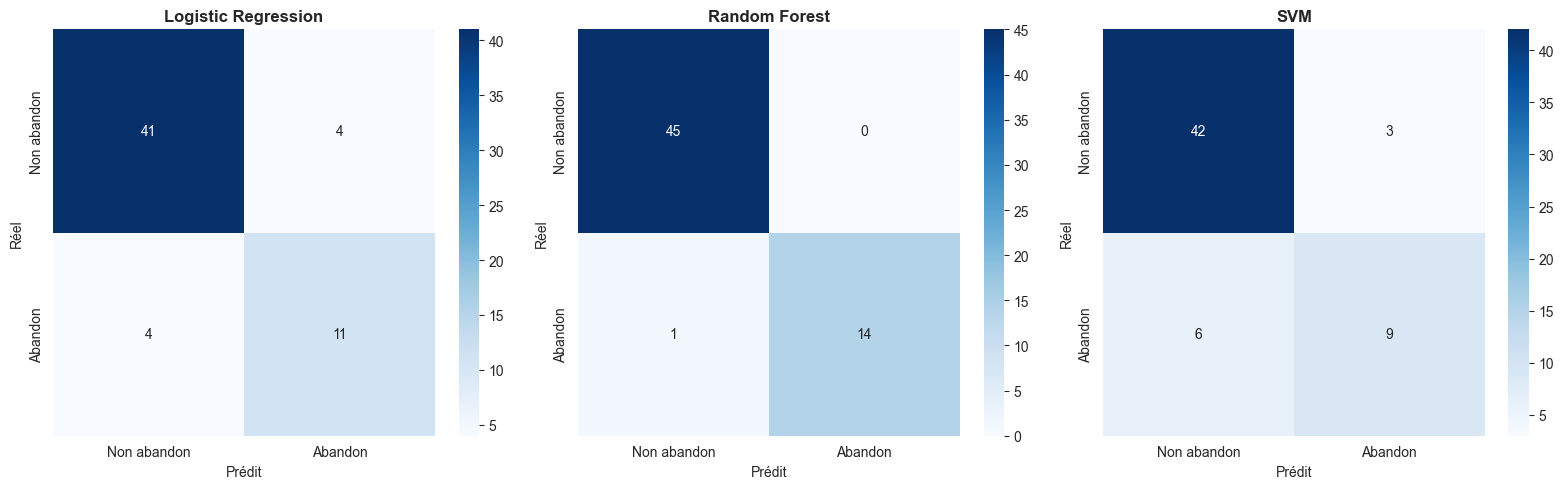


=== Rapport détaillé : Random Forest ===

              precision    recall  f1-score   support

 Non abandon       0.98      1.00      0.99        45
     Abandon       1.00      0.93      0.97        15

    accuracy                           0.98        60
   macro avg       0.99      0.97      0.98        60
weighted avg       0.98      0.98      0.98        60



In [116]:
# Matrices de confusion pour chaque modèle
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non abandon', 'Abandon'],
                yticklabels=['Non abandon', 'Abandon'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
plt.tight_layout()
plt.savefig('../reports/figures/05_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Rapport détaillé du meilleur modèle 
best_name = results_df['F1-score'].idxmax()
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"\n=== Rapport détaillé : {best_name} ===\n")
print(classification_report(y_test, y_pred_best,
                            target_names=['Non abandon', 'Abandon']))

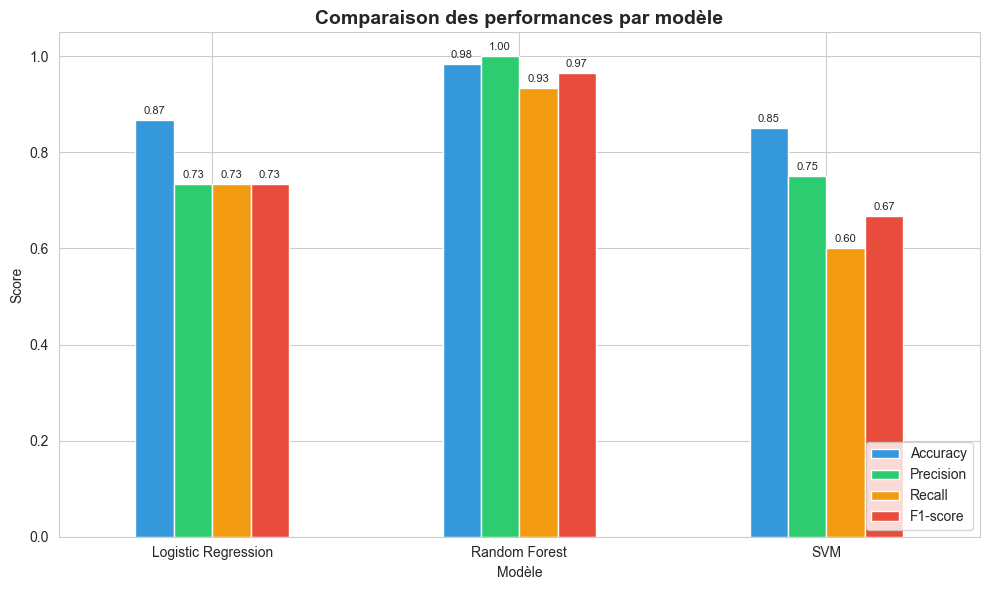


 Meilleur modèle (basé sur F1-score) : Random Forest
F1-score : 0.9655


In [117]:
# Visualisation comparative des F1-scores
fig, ax = plt.subplots(figsize=(10, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
)
ax.set_title('Comparaison des performances par modèle', fontweight='bold', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/06_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Meilleur modèle (basé sur F1-score) : {best_name}")
print(f"F1-score : {results_df.loc[best_name, 'F1-score']:.4f}")

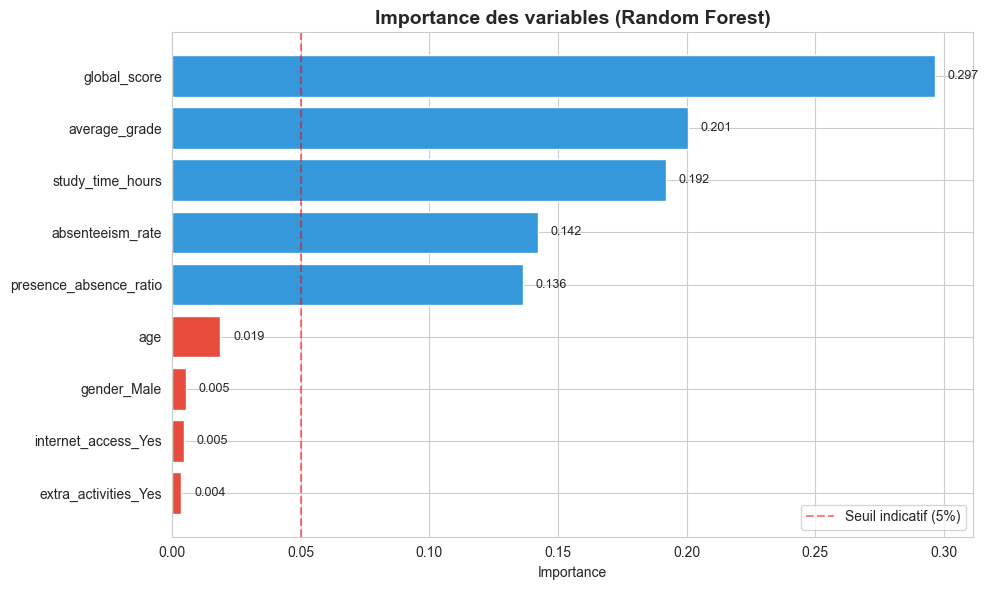


=== Top 5 variables les plus importantes ===
                  Feature  Importance
8            global_score    0.296511
1           average_grade    0.200533
3        study_time_hours    0.191988
2        absenteeism_rate    0.142194
7  presence_absence_ratio    0.136291


In [118]:
# Importance des features selon Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x < 0.05 else '#3498db' for x in feature_importance['Importance']]
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_title('Importance des variables (Random Forest)', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Seuil indicatif (5%)')
ax.legend()
for i, v in enumerate(feature_importance['Importance']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/07_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n=== Top 5 variables les plus importantes ===")
print(feature_importance.sort_values('Importance', ascending=False).head())

---
## 8. Optimisation des hyperparamètres (GridSearchCV)

Recherche des meilleurs hyperparamètres via GridSearchCV avec validation croisée 5-fold.
Test de `class_weight='balanced'` pour traiter le déséquilibre des classes (76/24).

In [119]:
from sklearn.model_selection import GridSearchCV

# Grilles d'hyperparamètres pour chaque modèle
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'solver': ['lbfgs']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'class_weight': [None, 'balanced']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.1],
        'kernel': ['rbf', 'linear'],
        'class_weight': [None, 'balanced']
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE)
}

# Recherche des meilleurs hyperparamètres
best_models = {}
optim_results = []

for name in base_models:
    print(f" GridSearch pour {name}...")
    grid = GridSearchCV(
        base_models[name],
        param_grids[name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    
    # Évaluation sur le test
    y_pred = grid.predict(X_test_scaled)
    optim_results.append({
        'Modèle': name,
        'Best F1 (CV)': grid.best_score_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'Best Params': grid.best_params_
    })
    print(f"    Meilleurs params : {grid.best_params_}")
    print(f"    Meilleur F1 (CV) : {grid.best_score_:.4f}\n")

optim_df = pd.DataFrame(optim_results).set_index('Modèle')
print("\n=== Résultats après optimisation ===")
print(optim_df[['Best F1 (CV)', 'Accuracy', 'Precision', 'Recall', 'F1-score']].round(4))

 GridSearch pour Logistic Regression...
    Meilleurs params : {'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
    Meilleur F1 (CV) : 0.7968

 GridSearch pour Random Forest...
    Meilleurs params : {'class_weight': None, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
    Meilleur F1 (CV) : 0.9546

 GridSearch pour SVM...
    Meilleurs params : {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
    Meilleur F1 (CV) : 0.7830


=== Résultats après optimisation ===
                     Best F1 (CV)  Accuracy  Precision  Recall  F1-score
Modèle                                                                  
Logistic Regression        0.7968    0.8333      0.619  0.8667    0.7222
Random Forest              0.9546    0.9833      1.000  0.9333    0.9655
SVM                        0.7830    0.8500      0.650  0.8667    0.7429


In [120]:
# Comparaison avant/après optimisation
comparison = pd.DataFrame({
    'F1 avant': results_df['F1-score'],
    'F1 après': optim_df['F1-score'],
    'Gain': optim_df['F1-score'] - results_df['F1-score']
})
print("=== Gain d'optimisation ===")
print(comparison.round(4))

# Meilleur modèle final
best_name_final = optim_df['F1-score'].idxmax()
best_model_final = best_models[best_name_final]
print(f"\n Modèle retenu : {best_name_final}")
print(f"   F1-score final : {optim_df.loc[best_name_final, 'F1-score']:.4f}")
print(f"   Accuracy final : {optim_df.loc[best_name_final, 'Accuracy']:.4f}")
print(f"   Hyperparamètres : {optim_df.loc[best_name_final, 'Best Params']}")

=== Gain d'optimisation ===
                     F1 avant  F1 après    Gain
Modèle                                         
Logistic Regression    0.7333    0.7222 -0.0111
Random Forest          0.9655    0.9655  0.0000
SVM                    0.6667    0.7429  0.0762

 Modèle retenu : Random Forest
   F1-score final : 0.9655
   Accuracy final : 0.9833
   Hyperparamètres : {'class_weight': None, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


---
## 9. Sauvegarde du modèle final

Sauvegarde du modèle, du scaler et de la liste des colonnes pour le déploiement Streamlit.

In [121]:
import joblib
from pathlib import Path

# Création dossier models 
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Sauvegarde du modèle, scaler, et schéma
artifacts = {
    'model': best_model_final,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_name': best_name_final,
    'metrics': {
        'accuracy': optim_df.loc[best_name_final, 'Accuracy'],
        'precision': optim_df.loc[best_name_final, 'Precision'],
        'recall': optim_df.loc[best_name_final, 'Recall'],
        'f1_score': optim_df.loc[best_name_final, 'F1-score']
    }
}

joblib.dump(artifacts, models_dir / 'best_model.pkl')
print(f" Modèle sauvegardé : {models_dir / 'best_model.pkl'}")
print(f"   Taille : {(models_dir / 'best_model.pkl').stat().st_size / 1024:.1f} KB")

# Test de rechargement
loaded = joblib.load(models_dir / 'best_model.pkl')
print(f"\n Modèle rechargé avec succès : {loaded['model_name']}")
print(f"   Features attendues : {loaded['feature_names']}")

 Modèle sauvegardé : ..\models\best_model.pkl
   Taille : 462.8 KB

 Modèle rechargé avec succès : Random Forest
   Features attendues : ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours', 'gender_Male', 'internet_access_Yes', 'extra_activities_Yes', 'presence_absence_ratio', 'global_score']


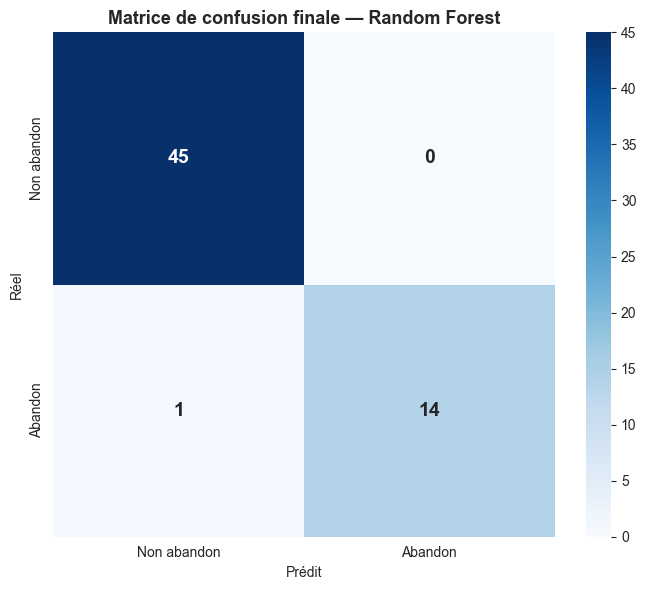


=== Rapport final — Random Forest ===

              precision    recall  f1-score   support

 Non abandon       0.98      1.00      0.99        45
     Abandon       1.00      0.93      0.97        15

    accuracy                           0.98        60
   macro avg       0.99      0.97      0.98        60
weighted avg       0.98      0.98      0.98        60



In [122]:
# Matrice de confusion finale du modèle retenu
y_pred_final = best_model_final.predict(X_test_scaled)
cm_final = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non abandon', 'Abandon'],
            yticklabels=['Non abandon', 'Abandon'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title(f'Matrice de confusion finale — {best_name_final}',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
plt.tight_layout()
plt.savefig('../reports/figures/08_final_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n=== Rapport final — {best_name_final} ===\n")
print(classification_report(y_test, y_pred_final,
                            target_names=['Non abandon', 'Abandon']))